## Computational Tight-Binding Model in One Dimension

We now implement the one-dimensional tight-binding chain described above.

The Hamiltonian matrix elements are

$$
H_{n,m}
=
\epsilon_0\delta_{n,m}
-
t
\left(
\delta_{n+1,m}
+
\delta_{n-1,m}
\right)
$$

where the indices are interpreted modulo $N$ because we impose periodic boundary conditions.

The parameter $\epsilon_0$ is the on-site energy,

$$
\epsilon_0=\epsilon_{\mathrm{atomic}}+V_0
$$

and $t$ is the nearest-neighbor hopping energy.

In matrix language, this Hamiltonian can be written as

$$
H
=
\epsilon_0 I
-
t
\left(
T+T^\dagger
\right)
$$

where $T$ is the cyclic shift operator satisfying

$$
T|n\rangle = |n+1\rangle
$$

with

$$
|N\rangle \equiv |0\rangle
$$

The goal of the code is to construct this Hamiltonian explicitly, diagonalize it, and compare the numerical eigenvalues with the analytic tight-binding dispersion

$$
E(k)
=
\epsilon_0
-
2t\cos(ka)
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

N = 16              # number of sites
a = 1.0             # lattice spacing
epsilon0 = 0.0      # on-site energy
t = 1.0             # nearest-neighbor hopping energy


# ------------------------------------------------------------
# Basis convention
# ------------------------------------------------------------
#
# The basis is
#
#     |0>, |1>, ..., |N-1>
#
# A state vector is represented by
#
#     phi = [phi_0, phi_1, ..., phi_{N-1}]^T
#
# The Hamiltonian acts on this coefficient vector.
# ------------------------------------------------------------


def cyclic_shift_matrix(N: int) -> np.ndarray:
    """
    Construct the cyclic shift operator T.

    The operator satisfies

        T |n> = |n+1>

    with periodic boundary condition

        |N> = |0>.

    In the chosen basis, the matrix element is

        T_{m,n} = 1 if m = n + 1 mod N.
    """
    T = np.zeros((N, N), dtype=float)

    for n in range(N):
        T[(n + 1) % N, n] = 1.0

    return T


def tight_binding_hamiltonian(
    N: int,
    epsilon0: float,
    t: float,
) -> np.ndarray:
    """
    Construct the one-dimensional nearest-neighbor tight-binding Hamiltonian

        H = epsilon0 I - t (T + T^dagger)

    with periodic boundary conditions.
    """
    I = np.eye(N)
    T = cyclic_shift_matrix(N)

    H = epsilon0 * I - t * (T + T.T)

    return H


H = tight_binding_hamiltonian(N=N, epsilon0=epsilon0, t=t)

print(H)

[[ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.  0. 

## Diagonalizing the Hamiltonian

The allowed energies are obtained from the matrix eigenvalue problem

$$
H\boldsymbol{\phi}^{(\alpha)}
=
E_\alpha \boldsymbol{\phi}^{(\alpha)}
$$

where $\alpha$ labels the eigenstate.

Because the Hamiltonian is real and symmetric, we use `np.linalg.eigh`, which is designed for Hermitian matrices.

In [4]:
eigenvalues, eigenvectors = np.linalg.eigh(H)

print("Numerical eigenvalues:")
print(eigenvalues)

Numerical eigenvalues:
[-2.00000000e+00 -1.84775907e+00 -1.84775907e+00 -1.41421356e+00
 -1.41421356e+00 -7.65366865e-01 -7.65366865e-01 -7.86779142e-16
  1.29941396e-15  7.65366865e-01  7.65366865e-01  1.41421356e+00
  1.41421356e+00  1.84775907e+00  1.84775907e+00  2.00000000e+00]


## Allowed Wave Vectors

For a periodic chain of length

$$
L=Na
$$

the allowed wave vectors are

$$
k_q
=
\frac{2\pi q}{Na}
$$

where $q$ is an integer.

A convenient numerical convention is to generate the allowed $k$ values using `np.fft.fftfreq`, then multiply by $2\pi$:

$$
k = 2\pi f
$$

where $f$ is the spatial frequency in cycles per unit length.

The analytic tight-binding energy is

$$
E(k)
=
\epsilon_0
-
2t\cos(ka)
$$

In [5]:
# Allowed wave vectors for a periodic chain
k_values = 2.0 * np.pi * np.fft.fftfreq(N, d=a)

# Analytic tight-binding dispersion evaluated at the allowed k values
E_analytic = epsilon0 - 2.0 * t * np.cos(k_values * a)

# Sort both sets for comparison
E_numerical_sorted = np.sort(eigenvalues)
E_analytic_sorted = np.sort(E_analytic)

print("Sorted numerical eigenvalues:")
print(E_numerical_sorted)

print("\nSorted analytic eigenvalues:")
print(E_analytic_sorted)

print("\nMaximum absolute difference:")
print(np.max(np.abs(E_numerical_sorted - E_analytic_sorted)))

Sorted numerical eigenvalues:
[-2.00000000e+00 -1.84775907e+00 -1.84775907e+00 -1.41421356e+00
 -1.41421356e+00 -7.65366865e-01 -7.65366865e-01 -7.86779142e-16
  1.29941396e-15  7.65366865e-01  7.65366865e-01  1.41421356e+00
  1.41421356e+00  1.84775907e+00  1.84775907e+00  2.00000000e+00]

Sorted analytic eigenvalues:
[-2.00000000e+00 -1.84775907e+00 -1.84775907e+00 -1.41421356e+00
 -1.41421356e+00 -7.65366865e-01 -7.65366865e-01 -1.22464680e-16
 -1.22464680e-16  7.65366865e-01  7.65366865e-01  1.41421356e+00
  1.41421356e+00  1.84775907e+00  1.84775907e+00  2.00000000e+00]

Maximum absolute difference:
1.887379141862766e-15


## Plotting the Discrete Energy Levels

For a finite chain, the allowed $k$ values are discrete. Therefore the energy spectrum consists of discrete points on the curve

$$
E(k)
=
\epsilon_0
-
2t\cos(ka)
$$

As $N$ becomes large, the allowed $k$ values become more closely spaced, and the discrete spectrum approaches a continuous band.

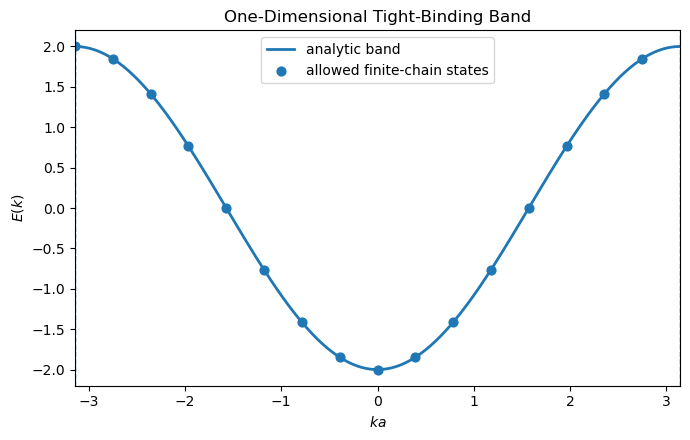

In [6]:
# Sort k values for plotting
sort_index = np.argsort(k_values)
k_sorted = k_values[sort_index]
E_sorted_by_k = E_analytic[sort_index]

# Smooth curve for visual reference
k_dense = np.linspace(-np.pi / a, np.pi / a, 500)
E_dense = epsilon0 - 2.0 * t * np.cos(k_dense * a)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(k_dense * a, E_dense, linewidth=2, label="analytic band")
ax.scatter(k_sorted * a, E_sorted_by_k, s=40, label="allowed finite-chain states")

ax.set_xlabel(r"$ka$")
ax.set_ylabel(r"$E(k)$")
ax.set_title("One-Dimensional Tight-Binding Band")

ax.axvline(-np.pi, linestyle="--", linewidth=1)
ax.axvline(np.pi, linestyle="--", linewidth=1)

ax.set_xlim(-np.pi, np.pi)

ax.legend()
plt.tight_layout()
plt.show()

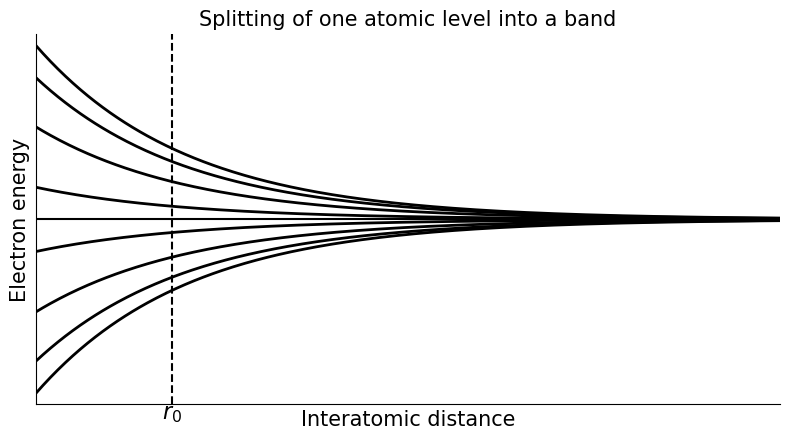

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------

N = 8                 # number of atoms / atomic orbitals
E0 = 0.0              # isolated atomic energy level
t0 = 0.35             # hopping strength at r0
beta = 2.0            # exponential decay rate
r0 = 1.0              # reference interatomic distance

r_values = np.linspace(0.55, 3.0, 400)

# ----------------------------
# Hamiltonian builder
# ----------------------------

def hopping(r, t0=t0, beta=beta, r0=r0):
    """
    Distance-dependent hopping matrix element.
    """
    return t0 * np.exp(-beta * (r - r0))


def build_hamiltonian(N, r, E0=E0):
    """
    Build the finite 1D tight-binding Hamiltonian
    in the localized atomic-orbital basis.

    Basis:
        |1>, |2>, ..., |N>

    Matrix:
        diagonal: E0
        nearest-neighbor off-diagonal: -t(r)
    """
    H = np.zeros((N, N))

    # diagonal atomic energy
    for i in range(N):
        H[i, i] = E0

    # nearest-neighbor hopping
    t = hopping(r)

    for i in range(N - 1):
        H[i, i + 1] = -t
        H[i + 1, i] = -t

    return H


# ----------------------------
# Diagonalize H(r) for each r
# ----------------------------

energy_levels = []

for r in r_values:
    H = build_hamiltonian(N, r)

    # Since H is real symmetric, use eigh
    eigenvalues, eigenvectors = np.linalg.eigh(H)

    energy_levels.append(eigenvalues)

energy_levels = np.array(energy_levels)

# Shape:
# energy_levels[j, n] = nth eigenvalue at r_values[j]

# ----------------------------
# Plot
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 4.5))

for n in range(N):
    ax.plot(
        r_values,
        energy_levels[:, n],
        color="black",
        linewidth=2.0
    )

# isolated atomic level
ax.axhline(E0, color="black", linewidth=1.5)

# reference spacing
ax.axvline(r0, color="black", linestyle="--", linewidth=1.5)

ax.text(
    r0,
    energy_levels.min() - 0.08,
    r"$r_0$",
    ha="center",
    va="top",
    fontsize=16
)

ax.set_xlabel("Interatomic distance", fontsize=15)
ax.set_ylabel("Electron energy", fontsize=15)

ax.set_xlim(r_values.min(), r_values.max())
ax.set_ylim(energy_levels.min() - 0.1, energy_levels.max() + 0.1)

ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Splitting of one atomic level into a band", fontsize=15)

plt.tight_layout()
plt.show()